<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_lab6_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Imports
import os
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)

DATA_DIR = "UCI_HAR_Dataset"
ZIP_PATH = "UCI_HAR_Dataset.zip"
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"


In [3]:
import os, zipfile, urllib.request

DATA_DIR = "UCI_HAR_Dataset"
ZIP_PATH = "UCI_HAR_Dataset.zip"
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

if not os.path.exists(ZIP_PATH):
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(URL, ZIP_PATH)

if not os.path.exists(DATA_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(".")

# See what actually got extracted
print("Top-level contents after extraction:", os.listdir("."))

# Case 1: it extracted straight to "UCI HAR Dataset"
if os.path.exists("UCI HAR Dataset") and not os.path.exists(DATA_DIR):
    os.rename("UCI HAR Dataset", DATA_DIR)

# Case 2: the outer zip contained a NESTED zip file instead of a folder
elif os.path.exists("UCI HAR Dataset.zip") and not os.path.exists(DATA_DIR):
    print("Found nested zip — extracting it too...")
    with zipfile.ZipFile("UCI HAR Dataset.zip", "r") as zf:
        zf.extractall(".")
    os.rename("UCI HAR Dataset", DATA_DIR)

print("Final:", os.listdir(DATA_DIR))

Top-level contents after extraction: ['.config', 'UCI HAR Dataset.names', 'UCI HAR Dataset.zip', 'UCI_HAR_Dataset.zip', 'sample_data']
Found nested zip — extracting it too...
Final: ['README.txt', '.DS_Store', 'activity_labels.txt', 'test', 'features.txt', 'features_info.txt', 'train']


In [4]:
# 3. Load the raw inertial signal files (NOT the 561-feature vectors)
# Each signal file has shape (num_windows, 128) -> we stack 9 signals -> (num_windows, 128, 9)

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(subset):
    # subset is 'train' or 'test'
    signal_dir = os.path.join(DATA_DIR, subset, "Inertial Signals")
    data = []
    for sig in SIGNALS:
        fname = os.path.join(signal_dir, f"{sig}_{subset}.txt")
        arr = np.loadtxt(fname)          # shape (num_windows, 128)
        data.append(arr)
    # stack along last axis -> (num_windows, 128, 9)
    X = np.stack(data, axis=-1)
    return X

def load_labels(subset):
    fname = os.path.join(DATA_DIR, subset, f"y_{subset}.txt")
    y = np.loadtxt(fname).astype(int) - 1   # labels are 1-indexed in the raw files -> make 0-indexed
    return y

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full  = load_signals("test")
y_test_full  = load_labels("test")

print("Raw train shape:", X_train_full.shape, y_train_full.shape)
print("Raw test  shape:", X_test_full.shape, y_test_full.shape)


Raw train shape: (7352, 128, 9) (7352,)
Raw test  shape: (2947, 128, 9) (2947,)


In [5]:
# 4. Recommended laboratory subset (1500-3000 windows, all 6 classes, balanced)
ACTIVITIES = {
    0: "WALKING", 1: "WALKING_UPSTAIRS", 2: "WALKING_DOWNSTAIRS",
    3: "SITTING", 4: "STANDING", 5: "LAYING"
}
NUM_CLASSES = 6
SUBSET_SIZE = 2400   # within the 1500-3000 recommendation

def balanced_subset(X, y, total):
    per_class = total // NUM_CLASSES
    idx_selected = []
    rng = np.random.default_rng(42)
    for c in range(NUM_CLASSES):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        idx_selected.append(idx_c[:per_class])
    idx_selected = np.concatenate(idx_selected)
    rng.shuffle(idx_selected)
    return X[idx_selected], y[idx_selected]

X_sub, y_sub = balanced_subset(X_train_full, y_train_full, SUBSET_SIZE)
print("Subset shape:", X_sub.shape, y_sub.shape)
print("Class distribution:", np.bincount(y_sub))


Subset shape: (2400, 128, 9) (2400,)
Class distribution: [400 400 400 400 400 400]


In [6]:
# 5. Train / validation / test split (70/15/15) -- test set kept fully separate
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, random_state=42, stratify=y_sub
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Before normalization:")
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Before normalization:
Train: (1680, 128, 9)  Val: (360, 128, 9)  Test: (360, 128, 9)


In [7]:
# 6. Normalize using TRAIN statistics only (per-channel mean/std)
mean = X_train.mean(axis=(0, 1), keepdims=True)   # shape (1,1,9)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_val_n   = (X_val   - mean) / std
X_test_n  = (X_test  - mean) / std


In [8]:
# 7. Required printed preprocessing output
print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")
print()
print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (val)  :", np.bincount(y_val))
print("Class distribution (test) :", np.bincount(y_test))


Input tensor shape:
  Training   : (1680, 128, 9)
  Validation : (360, 128, 9)
  Testing    : (360, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train): [280 280 280 280 280 280]
Class distribution (val)  : [60 60 60 60 60 60]
Class distribution (test) : [60 60 60 60 60 60]


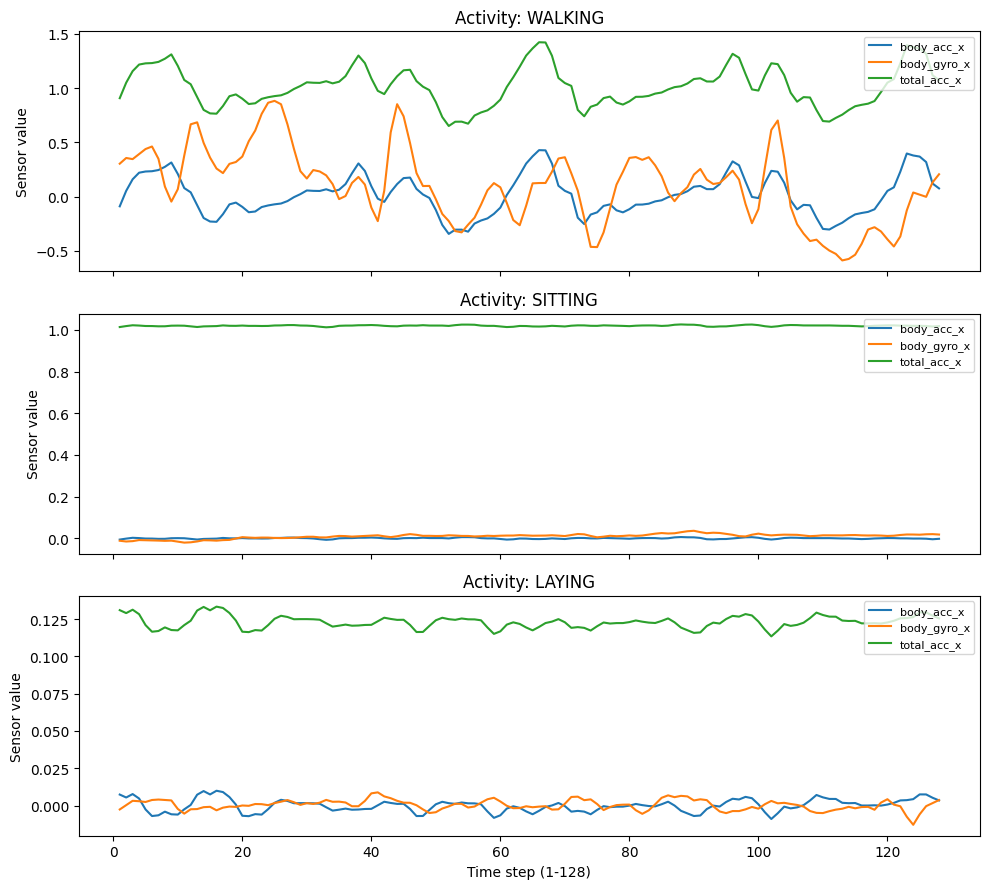

In [9]:
# 8. Plot 1: Sensor signal vs time (>=3 channels, >=3 activity classes)
channels_to_plot = [0, 3, 6]   # body_acc_x, body_gyro_x, total_acc_x
channel_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
classes_to_plot = [0, 3, 5]    # WALKING, SITTING, LAYING

fig, axes = plt.subplots(len(classes_to_plot), 1, figsize=(10, 9), sharex=True)
for row, cls in enumerate(classes_to_plot):
    idx = np.where(y_train == cls)[0][0]
    sample = X_train[idx]   # use un-normalized for interpretable units
    for ch, name in zip(channels_to_plot, channel_names):
        axes[row].plot(range(1, 129), sample[:, ch], label=name)
    axes[row].set_title(f"Activity: {ACTIVITIES[cls]}")
    axes[row].set_ylabel("Sensor value")
    axes[row].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
plt.tight_layout()
plt.savefig("plot1_signals_vs_time.png", dpi=150)
plt.show()


In [10]:
# 9. Save the prepared arrays for use in Parts 2-5 (avoids re-downloading/re-processing)
SAVE_DIR = "har_data"
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_train.npy", X_train_n)
np.save(f"{SAVE_DIR}/X_val.npy",   X_val_n)
np.save(f"{SAVE_DIR}/X_test.npy",  X_test_n)
np.save(f"{SAVE_DIR}/y_train.npy", y_train)
np.save(f"{SAVE_DIR}/y_val.npy",   y_val)
np.save(f"{SAVE_DIR}/y_test.npy",  y_test)

print("Saved preprocessed arrays to", SAVE_DIR)
print(os.listdir(SAVE_DIR))


Saved preprocessed arrays to har_data
['y_test.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'X_train.npy']


In [11]:
# 1. Imports and data loading
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR = "har_data"
X_train = np.load(f"{DATA_DIR}/X_train.npy")
X_val   = np.load(f"{DATA_DIR}/X_val.npy")
X_test  = np.load(f"{DATA_DIR}/X_test.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
NUM_CLASSES = 6

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1680, 128, 9) Val: (360, 128, 9) Test: (360, 128, 9)


In [12]:
# 2. Numerical Exercise - programmatic verification
x = [0.5, 0.7, 0.2]
Wx, Wh, b = 0.5, 0.8, 0.1
h = 0.0
h_values = []
for t, xt in enumerate(x, start=1):
    h = np.tanh(Wx * xt + Wh * h + b)
    h_values.append(h)
    print(f"h{t} = {h:.4f}")

print("\nProgrammatic h1,h2,h3:", [round(v, 4) for v in h_values])
print("Compare these against your manual calculation above.")


h1 = 0.3364
h2 = 0.6164
h3 = 0.6000

Programmatic h1,h2,h3: [np.float64(0.3364), np.float64(0.6164), np.float64(0.6)]
Compare these against your manual calculation above.


In [13]:
# 3. Build the RNN model
def build_rnn_model(input_shape=(128, 9), num_classes=6, units=32):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.SimpleRNN(units, name="simple_rnn"),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="Vanilla_RNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

rnn_model = build_rnn_model()
rnn_model.summary()


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 4. Train the RNN (30 epochs, batch size 32) and time it
start_time = time.time()
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)
rnn_train_time = time.time() - start_time
print(f"\nRNN training time: {rnn_train_time:.2f} seconds")


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.3798 - loss: 1.6375 - val_accuracy: 0.4528 - val_loss: 1.4103
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4577 - loss: 1.3469 - val_accuracy: 0.5167 - val_loss: 1.1928
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5304 - loss: 1.2231 - val_accuracy: 0.5833 - val_loss: 1.0426
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5863 - loss: 1.0419 - val_accuracy: 0.5861 - val_loss: 0.9428
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5810 - loss: 0.9217 - val_accuracy: 0.6056 - val_loss: 0.8158
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6190 - loss: 0.8086 - val_accuracy: 0.5556 - val_loss: 0.8761
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6101 - loss: 0.8435 - val_accuracy: 0.6000 - val_loss: 0.7546
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6452 - loss: 0.7533 - val_accuracy: 0.6472 - 

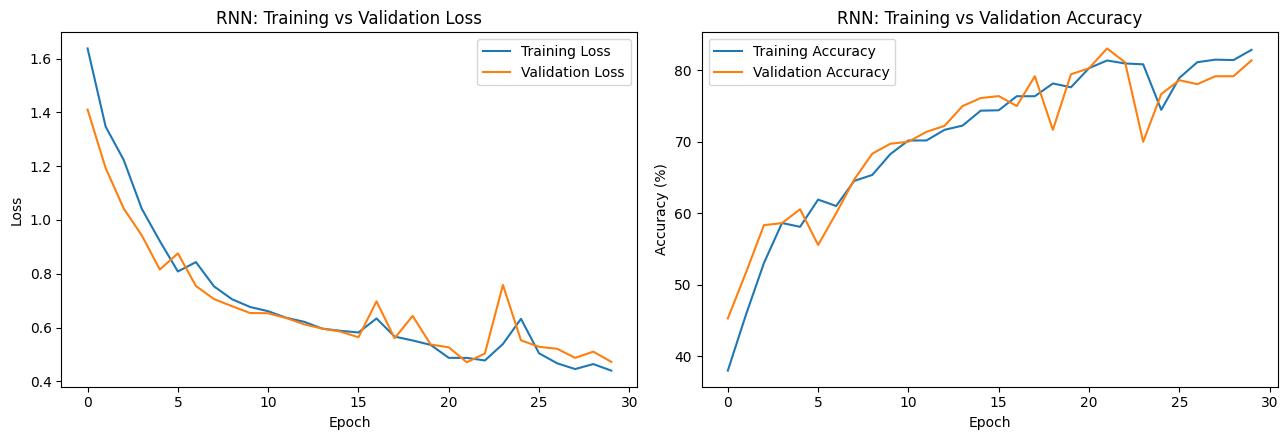

In [15]:
# 5. Plot 2 & Plot 3: Training/validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_rnn.history["loss"], label="Training Loss")
axes[0].plot(history_rnn.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("RNN: Training vs Validation Loss")
axes[0].legend()

axes[1].plot(np.array(history_rnn.history["accuracy"]) * 100, label="Training Accuracy")
axes[1].plot(np.array(history_rnn.history["val_accuracy"]) * 100, label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("RNN: Training vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot2_3_rnn_curves.png", dpi=150)
plt.show()


In [16]:
# 6. Evaluate on the untouched test set
y_pred_probs = rnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

rnn_accuracy  = accuracy_score(y_test, y_pred) * 100
rnn_precision = precision_score(y_test, y_pred, average="macro") * 100
rnn_recall    = recall_score(y_test, y_pred, average="macro") * 100
rnn_f1        = f1_score(y_test, y_pred, average="macro") * 100
rnn_params    = rnn_model.count_params()

print(f"Test Accuracy        : {rnn_accuracy:.2f}%")
print(f"Macro Precision      : {rnn_precision:.2f}%")
print(f"Macro Recall         : {rnn_recall:.2f}%")
print(f"Macro F1-score       : {rnn_f1:.2f}%")
print(f"Trainable parameters : {rnn_params}")
print(f"Training time (s)    : {rnn_train_time:.2f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Test Accuracy        : 81.39%
Macro Precision      : 81.36%
Macro Recall         : 81.39%
Macro F1-score       : 81.30%
Trainable parameters : 1974
Training time (s)    : 31.55


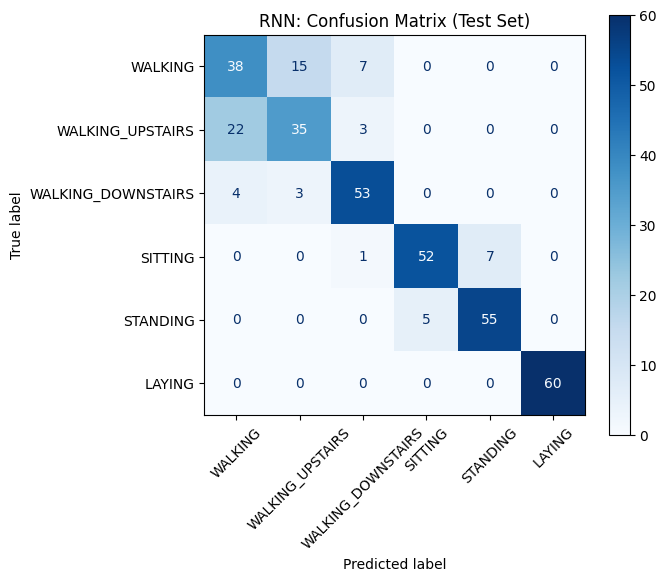

[[38 15  7  0  0  0]
 [22 35  3  0  0  0]
 [ 4  3 53  0  0  0]
 [ 0  0  1 52  7  0]
 [ 0  0  0  5 55  0]
 [ 0  0  0  0  0 60]]


In [17]:
# 7. Plot 4: Confusion Matrix (RNN)
cm_rnn = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnn, display_labels=ACTIVITIES)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("RNN: Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("plot4_rnn_confusion_matrix.png", dpi=150)
plt.show()

print(cm_rnn)


In [18]:
# 8. Save model + metrics for later consolidation (Part 8) and comparison (Part 5)
rnn_model.save("rnn_model.keras")

results_rnn = {
    "model": "RNN",
    "accuracy": rnn_accuracy,
    "precision": rnn_precision,
    "recall": rnn_recall,
    "f1": rnn_f1,
    "parameters": int(rnn_params),
    "training_time_sec": rnn_train_time,
    "history": {
        "loss": [float(v) for v in history_rnn.history["loss"]],
        "val_loss": [float(v) for v in history_rnn.history["val_loss"]],
        "accuracy": [float(v) for v in history_rnn.history["accuracy"]],
        "val_accuracy": [float(v) for v in history_rnn.history["val_accuracy"]],
    },
    "confusion_matrix": cm_rnn.tolist()
}

with open("results_rnn.json", "w") as f:
    json.dump(results_rnn, f, indent=2)

print("Saved rnn_model.keras and results_rnn.json")


Saved rnn_model.keras and results_rnn.json


In [19]:
# 1. Imports and data loading
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR = "har_data"
X_train = np.load(f"{DATA_DIR}/X_train.npy")
X_val   = np.load(f"{DATA_DIR}/X_val.npy")
X_test  = np.load(f"{DATA_DIR}/X_test.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
NUM_CLASSES = 6

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1680, 128, 9) Val: (360, 128, 9) Test: (360, 128, 9)


In [20]:
# 2. Build the LSTM model
def build_lstm_model(input_shape=(128, 9), num_classes=6, units=32):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, name="lstm"),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="LSTM_Model")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# 3. Train the LSTM (30 epochs, batch size 32) and time it
start_time = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)
lstm_train_time = time.time() - start_time
print(f"\nLSTM training time: {lstm_train_time:.2f} seconds")


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2982 - loss: 1.6799 - val_accuracy: 0.5056 - val_loss: 1.5484
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5774 - loss: 1.3196 - val_accuracy: 0.6944 - val_loss: 1.0327
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7048 - loss: 0.8373 - val_accuracy: 0.7833 - val_loss: 0.7055
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7345 - loss: 0.7083 - val_accuracy: 0.7806 - val_loss: 0.6095
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7899 - loss: 0.5666 - val_accuracy: 0.8417 - val_loss: 0.5052
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8119 - loss: 0.4838 - val_accuracy: 0.8583 - val_loss: 0.4355
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8595 - loss: 0.4213 - val_accuracy: 0.8833 - val_loss: 0.3873
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8815 - loss: 0.3586 - val_accuracy: 0.8944 - v

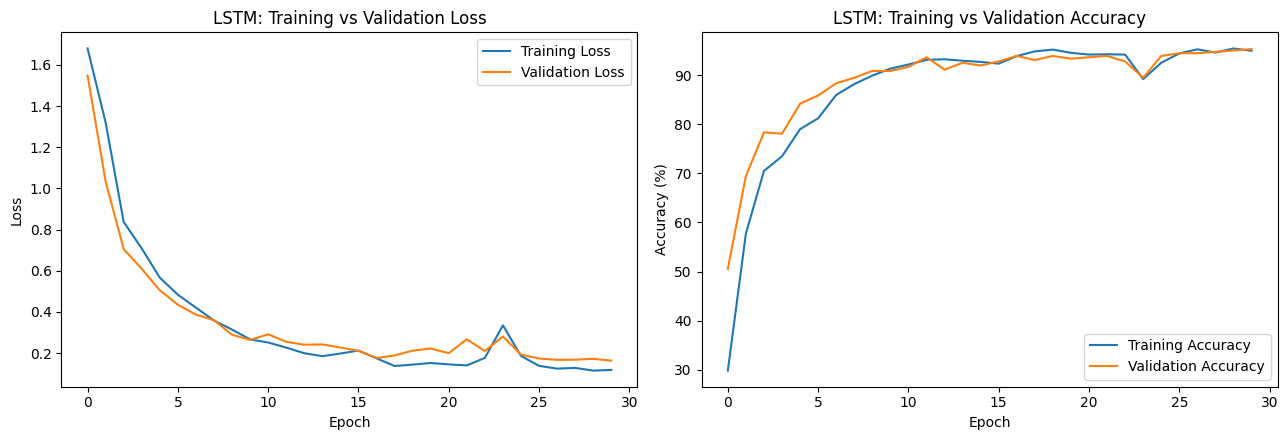

In [22]:
# 4. Plot 2 & Plot 3: Training/validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_lstm.history["loss"], label="Training Loss")
axes[0].plot(history_lstm.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("LSTM: Training vs Validation Loss")
axes[0].legend()

axes[1].plot(np.array(history_lstm.history["accuracy"]) * 100, label="Training Accuracy")
axes[1].plot(np.array(history_lstm.history["val_accuracy"]) * 100, label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("LSTM: Training vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot2_3_lstm_curves.png", dpi=150)
plt.show()


In [23]:
# 5. Evaluate on the untouched test set
y_pred_probs = lstm_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

lstm_accuracy  = accuracy_score(y_test, y_pred) * 100
lstm_precision = precision_score(y_test, y_pred, average="macro") * 100
lstm_recall    = recall_score(y_test, y_pred, average="macro") * 100
lstm_f1        = f1_score(y_test, y_pred, average="macro") * 100
lstm_params    = lstm_model.count_params()

print(f"Test Accuracy        : {lstm_accuracy:.2f}%")
print(f"Macro Precision      : {lstm_precision:.2f}%")
print(f"Macro Recall         : {lstm_recall:.2f}%")
print(f"Macro F1-score       : {lstm_f1:.2f}%")
print(f"Trainable parameters : {lstm_params}")
print(f"Training time (s)    : {lstm_train_time:.2f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Test Accuracy        : 93.89%
Macro Precision      : 94.22%
Macro Recall         : 93.89%
Macro F1-score       : 93.82%
Trainable parameters : 6006
Training time (s)    : 26.63


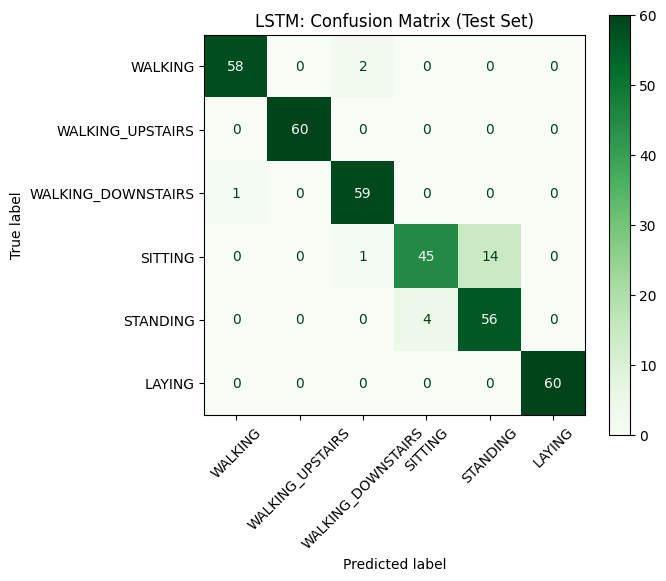

[[58  0  2  0  0  0]
 [ 0 60  0  0  0  0]
 [ 1  0 59  0  0  0]
 [ 0  0  1 45 14  0]
 [ 0  0  0  4 56  0]
 [ 0  0  0  0  0 60]]


In [24]:
# 6. Plot 4: Confusion Matrix (LSTM)
cm_lstm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=ACTIVITIES)
disp.plot(ax=ax, xticks_rotation=45, cmap="Greens", colorbar=True)
ax.set_title("LSTM: Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("plot4_lstm_confusion_matrix.png", dpi=150)
plt.show()

print(cm_lstm)


In [25]:
# 7. Save model + metrics for later consolidation (Part 8) and comparison (Part 5)
lstm_model.save("lstm_model.keras")

results_lstm = {
    "model": "LSTM",
    "accuracy": lstm_accuracy,
    "precision": lstm_precision,
    "recall": lstm_recall,
    "f1": lstm_f1,
    "parameters": int(lstm_params),
    "training_time_sec": lstm_train_time,
    "history": {
        "loss": [float(v) for v in history_lstm.history["loss"]],
        "val_loss": [float(v) for v in history_lstm.history["val_loss"]],
        "accuracy": [float(v) for v in history_lstm.history["accuracy"]],
        "val_accuracy": [float(v) for v in history_lstm.history["val_accuracy"]],
    },
    "confusion_matrix": cm_lstm.tolist()
}

with open("results_lstm.json", "w") as f:
    json.dump(results_lstm, f, indent=2)

print("Saved lstm_model.keras and results_lstm.json")


Saved lstm_model.keras and results_lstm.json


In [26]:
# 1. Imports and data loading
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR = "har_data"
X_train = np.load(f"{DATA_DIR}/X_train.npy")
X_val   = np.load(f"{DATA_DIR}/X_val.npy")
X_test  = np.load(f"{DATA_DIR}/X_test.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
NUM_CLASSES = 6

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1680, 128, 9) Val: (360, 128, 9) Test: (360, 128, 9)


In [27]:
# 2. Build the GRU model
def build_gru_model(input_shape=(128, 9), num_classes=6, units=32):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(units, name="gru"),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="GRU_Model")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

gru_model = build_gru_model()
gru_model.summary()


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 3. Train the GRU (30 epochs, batch size 32) and time it
start_time = time.time()
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)
gru_train_time = time.time() - start_time
print(f"\nGRU training time: {gru_train_time:.2f} seconds")


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3423 - loss: 1.6368 - val_accuracy: 0.4083 - val_loss: 1.4506
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4167 - loss: 1.3623 - val_accuracy: 0.4667 - val_loss: 1.2460
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4839 - loss: 1.1777 - val_accuracy: 0.6000 - val_loss: 1.0757
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6077 - loss: 1.0134 - val_accuracy: 0.6361 - val_loss: 0.9079
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6625 - loss: 0.8323 - val_accuracy: 0.7083 - val_loss: 0.7258
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7375 - loss: 0.6682 - val_accuracy: 0.8028 - val_loss: 0.5791
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8268 - loss: 0.5184 - val_accuracy: 0.8639 - val_loss: 0.4375
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8815 - loss: 0.3769 - val_accuracy: 0.9028 - v

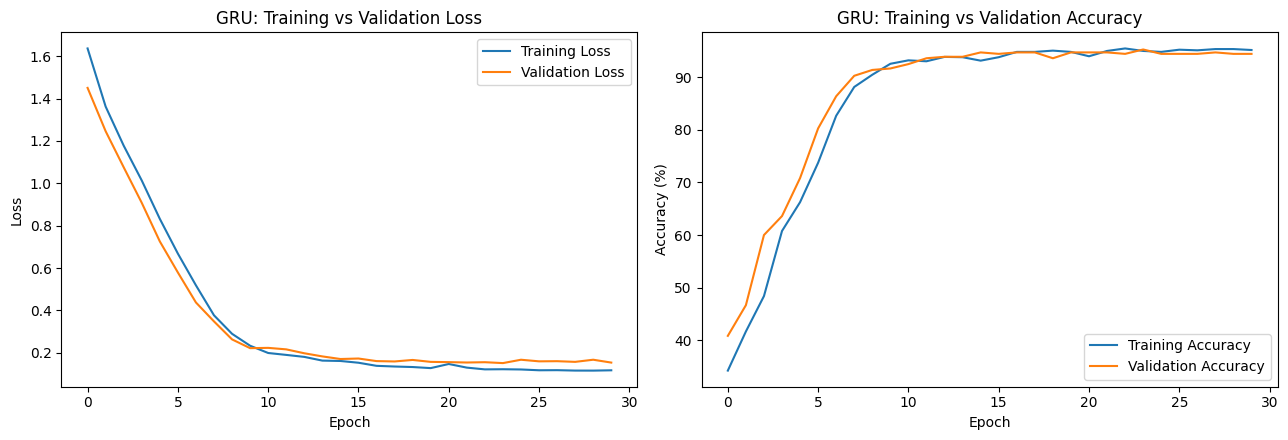

In [29]:
# 4. Plot 2 & Plot 3: Training/validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_gru.history["loss"], label="Training Loss")
axes[0].plot(history_gru.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("GRU: Training vs Validation Loss")
axes[0].legend()

axes[1].plot(np.array(history_gru.history["accuracy"]) * 100, label="Training Accuracy")
axes[1].plot(np.array(history_gru.history["val_accuracy"]) * 100, label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("GRU: Training vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot2_3_gru_curves.png", dpi=150)
plt.show()


In [30]:
# 5. Evaluate on the untouched test set
y_pred_probs = gru_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

gru_accuracy  = accuracy_score(y_test, y_pred) * 100
gru_precision = precision_score(y_test, y_pred, average="macro") * 100
gru_recall    = recall_score(y_test, y_pred, average="macro") * 100
gru_f1        = f1_score(y_test, y_pred, average="macro") * 100
gru_params    = gru_model.count_params()

print(f"Test Accuracy        : {gru_accuracy:.2f}%")
print(f"Macro Precision      : {gru_precision:.2f}%")
print(f"Macro Recall         : {gru_recall:.2f}%")
print(f"Macro F1-score       : {gru_f1:.2f}%")
print(f"Trainable parameters : {gru_params}")
print(f"Training time (s)    : {gru_train_time:.2f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test Accuracy        : 93.89%
Macro Precision      : 94.64%
Macro Recall         : 93.89%
Macro F1-score       : 93.76%
Trainable parameters : 4758
Training time (s)    : 23.70


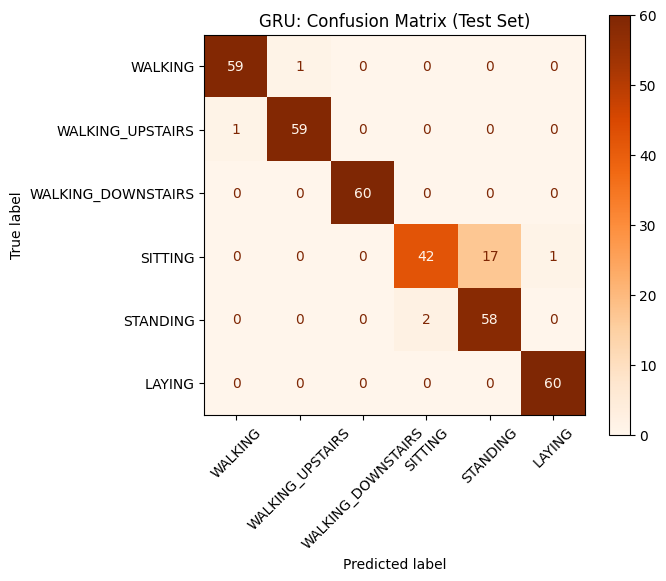

[[59  1  0  0  0  0]
 [ 1 59  0  0  0  0]
 [ 0  0 60  0  0  0]
 [ 0  0  0 42 17  1]
 [ 0  0  0  2 58  0]
 [ 0  0  0  0  0 60]]


In [31]:
# 6. Plot 4: Confusion Matrix (GRU)
cm_gru = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=ACTIVITIES)
disp.plot(ax=ax, xticks_rotation=45, cmap="Oranges", colorbar=True)
ax.set_title("GRU: Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("plot4_gru_confusion_matrix.png", dpi=150)
plt.show()

print(cm_gru)


In [32]:
# 7. Save model + metrics for later consolidation (Part 8) and comparison (Part 5)
gru_model.save("gru_model.keras")

results_gru = {
    "model": "GRU",
    "accuracy": gru_accuracy,
    "precision": gru_precision,
    "recall": gru_recall,
    "f1": gru_f1,
    "parameters": int(gru_params),
    "training_time_sec": gru_train_time,
    "history": {
        "loss": [float(v) for v in history_gru.history["loss"]],
        "val_loss": [float(v) for v in history_gru.history["val_loss"]],
        "accuracy": [float(v) for v in history_gru.history["accuracy"]],
        "val_accuracy": [float(v) for v in history_gru.history["val_accuracy"]],
    },
    "confusion_matrix": cm_gru.tolist()
}

with open("results_gru.json", "w") as f:
    json.dump(results_gru, f, indent=2)

print("Saved gru_model.keras and results_gru.json")


Saved gru_model.keras and results_gru.json


In [33]:
# 1. Imports and loading saved results from Parts 2-4
import os, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

tf.random.set_seed(42)
np.random.seed(42)

with open("results_rnn.json")  as f: results_rnn  = json.load(f)
with open("results_lstm.json") as f: results_lstm = json.load(f)
with open("results_gru.json")  as f: results_gru  = json.load(f)

print("Loaded results for:", results_rnn["model"], results_lstm["model"], results_gru["model"])


Loaded results for: RNN LSTM GRU


In [34]:
# 2. Completed comparison table
comparison_table = {
    "Property":            ["Hidden state", "Cell state", "Forget gate", "Input gate",
                             "Output gate", "Update gate", "Reset gate",
                             "Parameters", "Training time (s)", "Test F1-score (%)"],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No",
             results_rnn["parameters"], round(results_rnn["training_time_sec"], 2), round(results_rnn["f1"], 2)],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
             results_lstm["parameters"], round(results_lstm["training_time_sec"], 2), round(results_lstm["f1"], 2)],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes",
             results_gru["parameters"], round(results_gru["training_time_sec"], 2), round(results_gru["f1"], 2)],
}

import pandas as pd
df_compare = pd.DataFrame(comparison_table)
df_compare


,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time (s),31.55,26.63,23.7
9,Test F1-score (%),81.3,93.82,93.76


In [35]:
# Full performance-metrics table (Section 14 recap, all three models together)
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy (%)", "Macro Precision (%)", "Macro Recall (%)", "Macro F1 (%)",
               "Parameters", "Training Time (s)"],
    "RNN":  [round(results_rnn["accuracy"], 2), round(results_rnn["precision"], 2),
             round(results_rnn["recall"], 2), round(results_rnn["f1"], 2),
             results_rnn["parameters"], round(results_rnn["training_time_sec"], 2)],
    "LSTM": [round(results_lstm["accuracy"], 2), round(results_lstm["precision"], 2),
             round(results_lstm["recall"], 2), round(results_lstm["f1"], 2),
             results_lstm["parameters"], round(results_lstm["training_time_sec"], 2)],
    "GRU":  [round(results_gru["accuracy"], 2), round(results_gru["precision"], 2),
             round(results_gru["recall"], 2), round(results_gru["f1"], 2),
             results_gru["parameters"], round(results_gru["training_time_sec"], 2)],
})
metrics_table


,Metric,RNN,LSTM,GRU
0,Accuracy (%),81.39,93.89,93.89
1,Macro Precision (%),81.36,94.22,94.64
2,Macro Recall (%),81.39,93.89,93.89
3,Macro F1 (%),81.30,93.82,93.76
4,Parameters,1974.00,6006.00,4758.00
5,Training Time (s),31.55,26.63,23.70


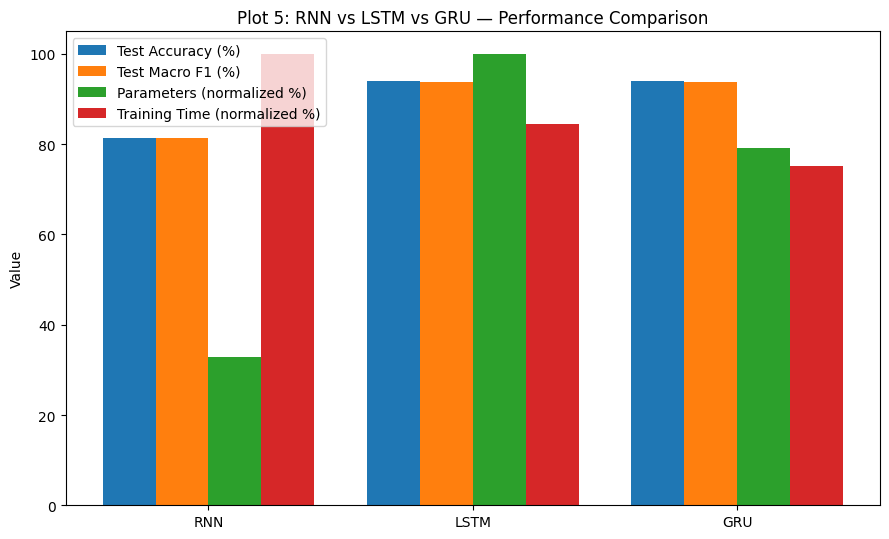

In [36]:
# 3. Plot 5: Model Performance Comparison (bar plot)
labels = ["RNN", "LSTM", "GRU"]
acc_vals = [results_rnn["accuracy"], results_lstm["accuracy"], results_gru["accuracy"]]
f1_vals  = [results_rnn["f1"], results_lstm["f1"], results_gru["f1"]]
params   = [results_rnn["parameters"], results_lstm["parameters"], results_gru["parameters"]]
times    = [results_rnn["training_time_sec"], results_lstm["training_time_sec"], results_gru["training_time_sec"]]

# normalize params and training time to 0-100 scale for comparability on the same axes
params_norm = [100 * p / max(params) for p in params]
times_norm  = [100 * t / max(times) for t in times]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - 1.5*width, acc_vals,    width, label="Test Accuracy (%)")
ax.bar(x - 0.5*width, f1_vals,     width, label="Test Macro F1 (%)")
ax.bar(x + 0.5*width, params_norm, width, label="Parameters (normalized %)")
ax.bar(x + 1.5*width, times_norm,  width, label="Training Time (normalized %)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Value")
ax.set_title("Plot 5: RNN vs LSTM vs GRU — Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot5_model_comparison.png", dpi=150)
plt.show()


In [37]:
# 4. Load full-length data and build truncated versions
DATA_DIR = "har_data"
X_train_full = np.load(f"{DATA_DIR}/X_train.npy")
X_val_full   = np.load(f"{DATA_DIR}/X_val.npy")
X_test_full  = np.load(f"{DATA_DIR}/X_test.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

SEQ_LENGTHS = [32, 64, 128]
SEQ_EPOCHS = 15   # reduced from 30 to keep this 9-model sweep light; raise if you have time/GPU budget

def truncate(X, T):
    return X[:, :T, :]

def build_model(layer_type, T, units=32, num_classes=6):
    rec_layer = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[layer_type]
    model = keras.Sequential([
        layers.Input(shape=(T, 9)),
        rec_layer(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


In [38]:
# 5. Sweep: train RNN/LSTM/GRU at each sequence length, record test F1
seq_length_results = {"RNN": {}, "LSTM": {}, "GRU": {}}

for T in SEQ_LENGTHS:
    Xtr = truncate(X_train_full, T)
    Xva = truncate(X_val_full, T)
    Xte = truncate(X_test_full, T)
    for model_type in ["RNN", "LSTM", "GRU"]:
        print(f"\n--- Training {model_type} at T={T} ---")
        tf.random.set_seed(42)
        m = build_model(model_type, T)
        m.fit(Xtr, y_train, validation_data=(Xva, y_val),
              epochs=SEQ_EPOCHS, batch_size=32, verbose=0)
        y_pred = np.argmax(m.predict(Xte, verbose=0), axis=1)
        f1 = f1_score(y_test, y_pred, average="macro") * 100
        seq_length_results[model_type][T] = f1
        print(f"{model_type} @ T={T}: Macro F1 = {f1:.2f}%")
        keras.backend.clear_session()

print("\nFull results:", seq_length_results)



--- Training RNN at T=32 ---
RNN @ T=32: Macro F1 = 72.01%

--- Training LSTM at T=32 ---
LSTM @ T=32: Macro F1 = 92.14%

--- Training GRU at T=32 ---
GRU @ T=32: Macro F1 = 92.74%

--- Training RNN at T=64 ---
RNN @ T=64: Macro F1 = 71.67%

--- Training LSTM at T=64 ---
LSTM @ T=64: Macro F1 = 92.72%

--- Training GRU at T=64 ---
GRU @ T=64: Macro F1 = 92.08%

--- Training RNN at T=128 ---
RNN @ T=128: Macro F1 = 75.92%

--- Training LSTM at T=128 ---
LSTM @ T=128: Macro F1 = 78.24%

--- Training GRU at T=128 ---
GRU @ T=128: Macro F1 = 92.48%

Full results: {'RNN': {32: 72.01124692641132, 64: 71.66543103868555, 128: 75.9160932187248}, 'LSTM': {32: 92.13977920006627, 64: 92.7180706890661, 128: 78.24291327238964}, 'GRU': {32: 92.74468014538381, 64: 92.0800700988822, 128: 92.47507457121853}}


In [39]:
# 6. Required table: Sequence Length vs Test F1-score
seq_table = pd.DataFrame({
    "Sequence Length": SEQ_LENGTHS,
    "RNN F1":  [round(seq_length_results["RNN"][T], 2) for T in SEQ_LENGTHS],
    "LSTM F1": [round(seq_length_results["LSTM"][T], 2) for T in SEQ_LENGTHS],
    "GRU F1":  [round(seq_length_results["GRU"][T], 2) for T in SEQ_LENGTHS],
})
seq_table


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,72.01,92.14,92.74
1,64,71.67,92.72,92.08
2,128,75.92,78.24,92.48


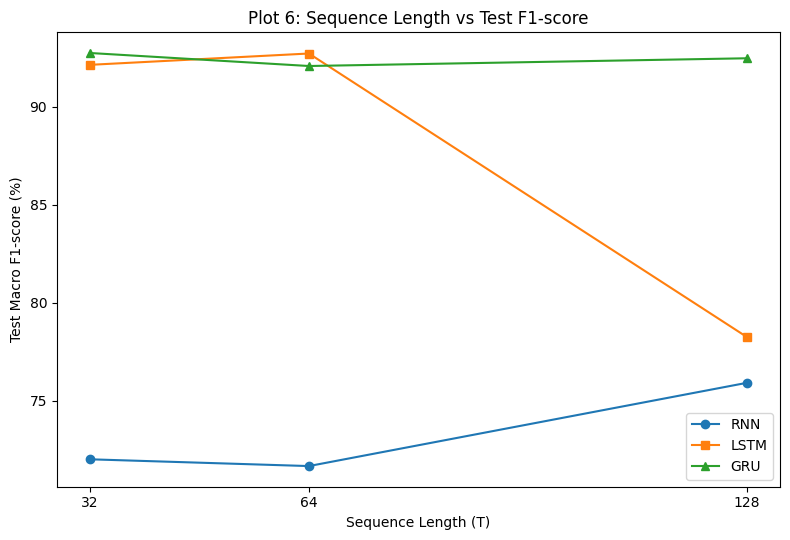

In [40]:
# 7. Plot 6: Sequence Length vs Test F1-score
fig, ax = plt.subplots(figsize=(8, 5.5))
for model_type, marker in zip(["RNN", "LSTM", "GRU"], ["o", "s", "^"]):
    vals = [seq_length_results[model_type][T] for T in SEQ_LENGTHS]
    ax.plot(SEQ_LENGTHS, vals, marker=marker, label=model_type)
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Plot 6: Sequence Length vs Test F1-score")
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
plt.tight_layout()
plt.savefig("plot6_seq_length_vs_f1.png", dpi=150)
plt.show()


In [41]:
# 8. Save sequence-length results for the consolidated report (Part 8)
with open("results_seq_length.json", "w") as f:
    json.dump(seq_length_results, f, indent=2)
print("Saved results_seq_length.json")


Saved results_seq_length.json


In [42]:
# 1. Setup: system deps + imports
!apt-get -qq install -y unrar > /dev/null
!pip -q install rarfile opencv-python-headless

import os, glob, json, time, random
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

SELECTED_CLASSES = ["Basketball", "Biking", "WalkingWithDog", "JumpingJack", "TennisSwing"]
NUM_VIDEOS_PER_CLASS = 12     # small subset per class, as recommended
NUM_FRAMES = 10
FRAME_SIZE = 224


In [43]:
import ssl
import urllib.request

UCF_URL = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
RAR_PATH = "UCF101.rar"

if not os.path.exists(RAR_PATH):
    print("Downloading UCF101.rar (large file, this may take a while)...")
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(UCF_URL, context=ctx) as response, open(RAR_PATH, "wb") as out_file:
        import shutil
        shutil.copyfileobj(response, out_file)
    print("Download complete.")

Download complete.


In [47]:
VIDEO_DIR = "videos"

In [48]:
# 3. Section 19: uniformly sample 10 frames per video, resize to 224x224x3
def sample_frames(video_path, num_frames=NUM_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((size, size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (size, size))
        frames.append(frame)
    cap.release()
    return np.stack(frames)   # (num_frames, 224, 224, 3)

# Collect video paths + labels
video_paths, video_labels = [], []
for cls in SELECTED_CLASSES:
    for vp in glob.glob(os.path.join(VIDEO_DIR, cls, "*.avi")):
        video_paths.append(vp)
        video_labels.append(cls)

print(f"Total videos collected: {len(video_paths)}")
print({c: video_labels.count(c) for c in SELECTED_CLASSES})


Total videos collected: 0
{'Basketball': 0, 'Biking': 0, 'WalkingWithDog': 0, 'JumpingJack': 0, 'TennisSwing': 0}


In [49]:
import os, glob
print("Does UCF101.rar exist?", os.path.exists("UCF101.rar"),
      os.path.getsize("UCF101.rar") if os.path.exists("UCF101.rar") else "N/A")
print("Does UCF101_full/ exist?", os.path.exists("UCF101_full"))
print("Does videos/ exist?", os.path.exists("videos"))
if os.path.exists("videos"):
    for cls in os.listdir("videos"):
        n = len(glob.glob(f"videos/{cls}/*.avi"))
        print(f"  {cls}: {n} videos")

Does UCF101.rar exist? True 1084046883
Does UCF101_full/ exist? False
Does videos/ exist? False


In [50]:
import rarfile
with rarfile.RarFile("UCF101.rar") as rf:
    names = rf.namelist()
    print(names[:5])   # show a few real filenames from inside the archive

['UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi', 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c02.avi', 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c03.avi', 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c04.avi', 'UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c05.avi']


In [51]:
import rarfile, os

EXTRACT_DIR = "UCF101_full"
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with rarfile.RarFile("UCF101.rar") as rf:
        names = rf.namelist()
        to_extract = [n for n in names if any(f"v_{c}_" in n for c in SELECTED_CLASSES)]
        rf.extractall(EXTRACT_DIR, members=to_extract)
    print(f"Extracted {len(to_extract)} files for classes: {SELECTED_CLASSES}")
else:
    print("EXTRACT_DIR already exists — checking contents...")
    import glob
    print(len(glob.glob(f"{EXTRACT_DIR}/**/*.avi", recursive=True)), "avi files found inside it")

Extracted 268 files for classes: ['Basketball', 'Biking', 'WalkingWithDog', 'JumpingJack', 'TennisSwing']


In [52]:
import glob
VIDEO_DIR = "videos"
os.makedirs(VIDEO_DIR, exist_ok=True)
all_videos = glob.glob(os.path.join(EXTRACT_DIR, "**", "*.avi"), recursive=True)
print("Total avi files found:", len(all_videos))

for cls in SELECTED_CLASSES:
    cls_dir = os.path.join(VIDEO_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    cls_videos = [v for v in all_videos if f"v_{cls}_" in os.path.basename(v)][:NUM_VIDEOS_PER_CLASS]
    for v in cls_videos:
        link_path = os.path.join(cls_dir, os.path.basename(v))
        if not os.path.exists(link_path):
            os.symlink(os.path.abspath(v), link_path)
    print(f"{cls}: {len(cls_videos)} videos")

Total avi files found: 268
Basketball: 12 videos
Biking: 12 videos
WalkingWithDog: 0 videos
JumpingJack: 0 videos
TennisSwing: 0 videos


In [53]:
video_paths, video_labels = [], []
for cls in SELECTED_CLASSES:
    for vp in glob.glob(os.path.join(VIDEO_DIR, cls, "*.avi")):
        video_paths.append(vp)
        video_labels.append(cls)
print(f"Total videos collected: {len(video_paths)}")

Total videos collected: 24


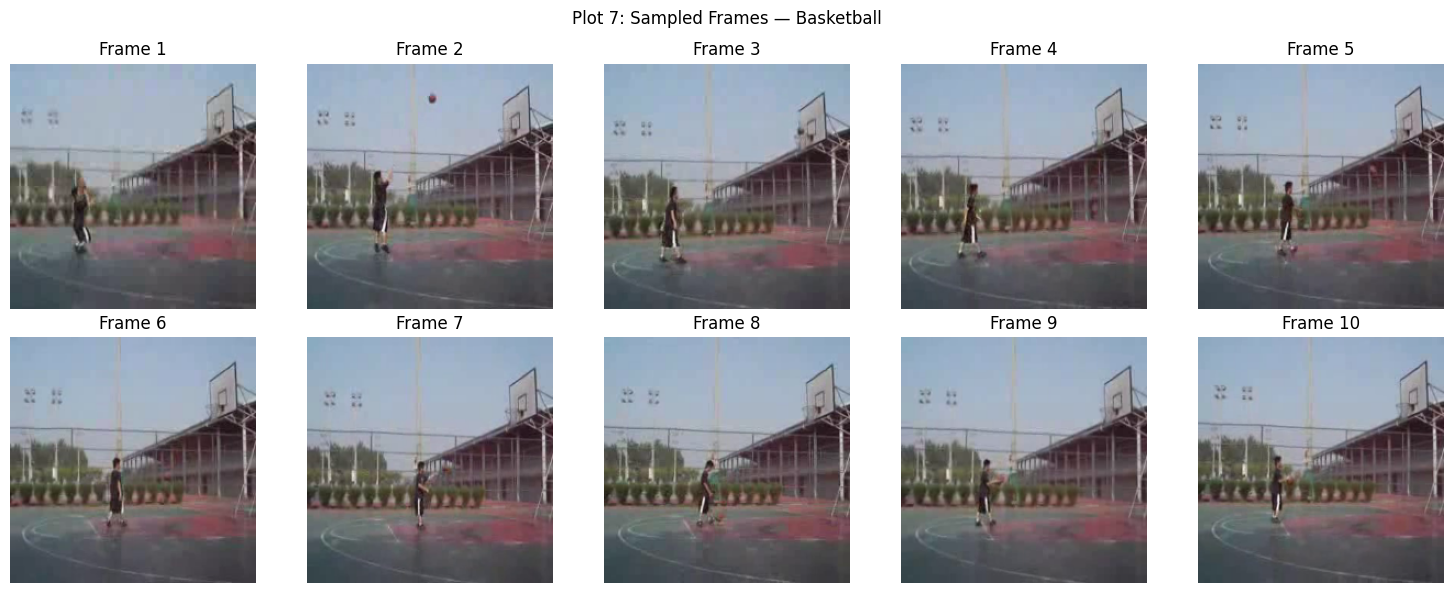

In [54]:
# Plot 7: Video Sample Frames - display one video's sampled frames
sample_video = video_paths[0]
sample_frames_arr = sample_frames(sample_video)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_frames_arr[i])
    ax.set_title(f"Frame {i+1}")
    ax.axis("off")
fig.suptitle(f"Plot 7: Sampled Frames — {video_labels[0]}")

plt.tight_layout()
plt.savefig("plot7_video_sample_frames.png", dpi=150)
plt.show()


In [55]:
# 4. Build the frozen CNN feature extractor
base_cnn = MobileNetV2(include_top=False, weights="imagenet", pooling="avg",
                        input_shape=(FRAME_SIZE, FRAME_SIZE, 3))
base_cnn.trainable = False   # freeze - do not train the CNN
FEATURE_DIM = base_cnn.output_shape[-1]
print(f"CNN feature dimension D = {FEATURE_DIM}")

def extract_features_for_video(video_path):
    frames = sample_frames(video_path)
    if frames is None:
        return None
    x = preprocess_input(frames.astype(np.float32))
    feats = base_cnn.predict(x, verbose=0)   # (10, D)
    return feats

# Extract features for every collected video -> X shape (num_videos, 10, D)
X_video_features = []
y_video_labels = []
start = time.time()
for vp, lbl in zip(video_paths, video_labels):
    feats = extract_features_for_video(vp)
    if feats is not None:
        X_video_features.append(feats)
        y_video_labels.append(lbl)
print(f"Feature extraction took {time.time()-start:.1f}s")

X_video_features = np.stack(X_video_features)   # (N, 10, D)
class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}
y_video_labels_idx = np.array([class_to_idx[l] for l in y_video_labels])

print("Feature tensor shape (N, 10, D):", X_video_features.shape)
print("Labels shape:", y_video_labels_idx.shape)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN feature dimension D = 1280
Feature extraction took 17.8s
Feature tensor shape (N, 10, D): (24, 10, 1280)
Labels shape: (24,)


In [56]:
# 5. Train/val/test split for the video task
Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
    X_video_features, y_video_labels_idx, test_size=0.30, random_state=42,
    stratify=y_video_labels_idx
)
Xv_val, Xv_test, yv_val, yv_test = train_test_split(
    Xv_temp, yv_temp, test_size=0.50, random_state=42, stratify=yv_temp
)
print("Video train/val/test:", Xv_train.shape, Xv_val.shape, Xv_test.shape)


Video train/val/test: (16, 10, 1280) (4, 10, 1280) (4, 10, 1280)


In [57]:
# 6. Build and train CNN-LSTM and CNN-GRU classifiers on the extracted features
def build_video_classifier(rec_type, feature_dim, num_classes):
    rec_layer = layers.LSTM if rec_type == "LSTM" else layers.GRU
    model = keras.Sequential([
        layers.Input(shape=(NUM_FRAMES, feature_dim)),
        rec_layer(32),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ], name=f"CNN_{rec_type}")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

VIDEO_EPOCHS = 25
video_results = {}
video_histories = {}

for rec_type in ["LSTM", "GRU"]:
    print(f"\n=== Training CNN-{rec_type} ===")
    tf.random.set_seed(42)
    model = build_video_classifier(rec_type, FEATURE_DIM, len(SELECTED_CLASSES))
    start = time.time()
    hist = model.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val),
                      epochs=VIDEO_EPOCHS, batch_size=8, verbose=0)
    train_time = time.time() - start

    y_pred = np.argmax(model.predict(Xv_test, verbose=0), axis=1)
    acc = accuracy_score(yv_test, y_pred) * 100
    prec = precision_score(yv_test, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(yv_test, y_pred, average="macro", zero_division=0) * 100
    f1 = f1_score(yv_test, y_pred, average="macro", zero_division=0) * 100

    video_results[rec_type] = {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "parameters": int(model.count_params()), "training_time_sec": train_time,
        "y_pred": y_pred.tolist(), "y_test": yv_test.tolist()
    }
    video_histories[rec_type] = hist.history
    print(f"CNN-{rec_type}: Acc={acc:.2f}% F1={f1:.2f}% Params={model.count_params()} Time={train_time:.1f}s")



=== Training CNN-LSTM ===
CNN-LSTM: Acc=75.00% F1=73.33% Params=168229 Time=3.9s

=== Training CNN-GRU ===
CNN-GRU: Acc=100.00% F1=100.00% Params=126309 Time=3.9s


Reporting curves for: GRU


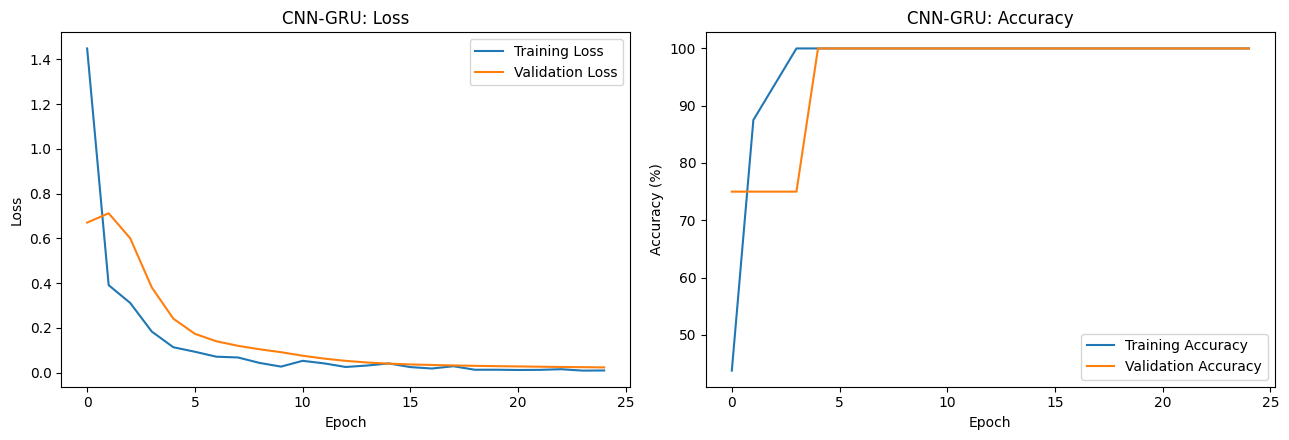

In [58]:
# Plot 8: Video Training and Validation Curves (for the selected recurrent architecture)
BEST_REC = max(video_results, key=lambda k: video_results[k]["f1"])   # pick better-performing head to report
print("Reporting curves for:", BEST_REC)

hist = video_histories[BEST_REC]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hist["loss"], label="Training Loss")
axes[0].plot(hist["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"CNN-{BEST_REC}: Loss")
axes[0].legend()

axes[1].plot(np.array(hist["accuracy"]) * 100, label="Training Accuracy")
axes[1].plot(np.array(hist["val_accuracy"]) * 100, label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title(f"CNN-{BEST_REC}: Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot8_video_training_curves.png", dpi=150)
plt.show()


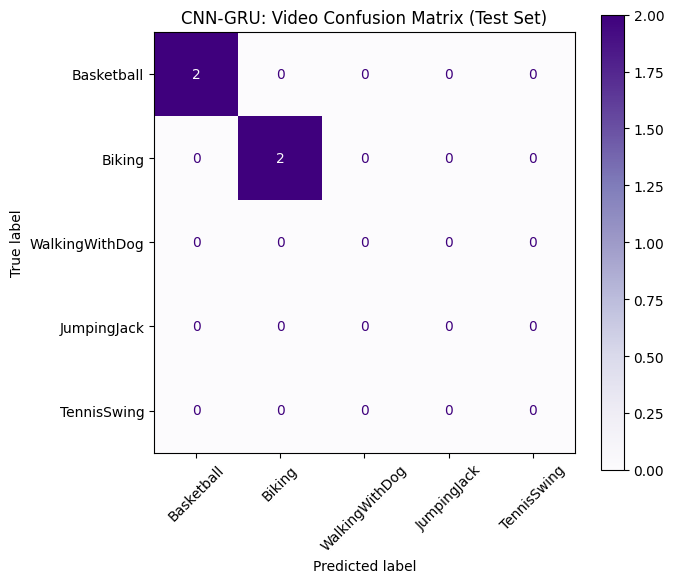

In [63]:
cm_video = confusion_matrix(
    video_results[BEST_REC]["y_test"],
    video_results[BEST_REC]["y_pred"],
    labels=list(range(len(SELECTED_CLASSES)))   # force all 5 classes, even if some are missing from this split
)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_video, display_labels=SELECTED_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, cmap="Purples", colorbar=True)
ax.set_title(f"CNN-{BEST_REC}: Video Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("plot9_video_confusion_matrix.png", dpi=150)
plt.show()

In [64]:
# 7. Save results for the consolidated report (Part 8)
with open("results_video.json", "w") as f:
    json.dump({
        "feature_dim": int(FEATURE_DIM),
        "classes": SELECTED_CLASSES,
        "best_model_reported": BEST_REC,
        "results": {k: {kk: vv for kk, vv in v.items() if kk not in ("y_pred", "y_test")}
                    for k, v in video_results.items()}
    }, f, indent=2)
print("Saved results_video.json")


Saved results_video.json


In [65]:
# 1. Imports and synthetic dataset generation
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json, time
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)

SEQ_LEN = 4
VOCAB_MIN, VOCAB_MAX = 0, 9        # digits used in the sequences
NUM_DIGITS = VOCAB_MAX - VOCAB_MIN + 1
START_TOKEN = NUM_DIGITS           # index 10, used only as the decoder's first input
VOCAB_SIZE = NUM_DIGITS + 1        # 10 digits + START token

NUM_SAMPLES = 20000

def generate_dataset(n, seq_len=SEQ_LEN):
    X = np.random.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n, seq_len))
    Y = X[:, ::-1].copy()          # target = reversed input
    return X, Y

X_all, Y_all = generate_dataset(NUM_SAMPLES)
print("Example pair:", X_all[0], "->", Y_all[0])
print("X_all shape:", X_all.shape, "Y_all shape:", Y_all.shape)


Example pair: [6 3 7 4] -> [4 7 3 6]
X_all shape: (20000, 4) Y_all shape: (20000, 4)


In [66]:
# 2. Train/val/test split, and build decoder-input (teacher-forced, START-shifted) sequences
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(X_all, Y_all, test_size=0.30, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)

def make_decoder_input(Y):
    # prepend START token, drop last true token -> teacher-forced decoder input
    dec_in = np.zeros_like(Y)
    dec_in[:, 0] = START_TOKEN
    dec_in[:, 1:] = Y[:, :-1]
    return dec_in

decIn_train, decIn_val, decIn_test = make_decoder_input(Y_train), make_decoder_input(Y_val), make_decoder_input(Y_test)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (14000, 4) Val: (3000, 4) Test: (3000, 4)


In [67]:
# 3. Build the encoder-decoder (LSTM) model with teacher forcing for training
EMBED_DIM = 16
LATENT_DIM = 64

# --- Encoder ---
encoder_inputs = layers.Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding")(encoder_inputs)
encoder_lstm = layers.LSTM(LATENT_DIM, return_state=True, name="encoder_lstm")
_, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# --- Decoder (training mode, teacher forced) ---
decoder_inputs = layers.Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = layers.Dense(VOCAB_SIZE, activation="softmax", name="decoder_output")
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="Seq2Seq_Reversal")
seq2seq_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()


Model: "Seq2Seq_Reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 4, 16)     │        176 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 4, 16)     │        176 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     20,736 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     20,736 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 4, 11)     │        715 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,539 (166.17 KB)

 Trainable params: 42,539 (166.17 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# 4. Train
start_time = time.time()
history_seq2seq = seq2seq_model.fit(
    [X_train, decIn_train], Y_train,
    validation_data=([X_val, decIn_val], Y_val),
    epochs=40, batch_size=64, verbose=1
)
seq2seq_train_time = time.time() - start_time
print(f"\nSeq2seq training time: {seq2seq_train_time:.2f}s")


Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4213 - loss: 1.6011 - val_accuracy: 0.8651 - val_loss: 0.6153
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9713 - loss: 0.2562 - val_accuracy: 0.9973 - val_loss: 0.1038
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9993 - loss: 0.0637 - val_accuracy: 0.9999 - val_loss: 0.0404
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 0.0206
Epoch 5/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 1.0000 - val_loss: 0.0126
Epoch 6/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 7/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.0061
Epoch 8/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy:

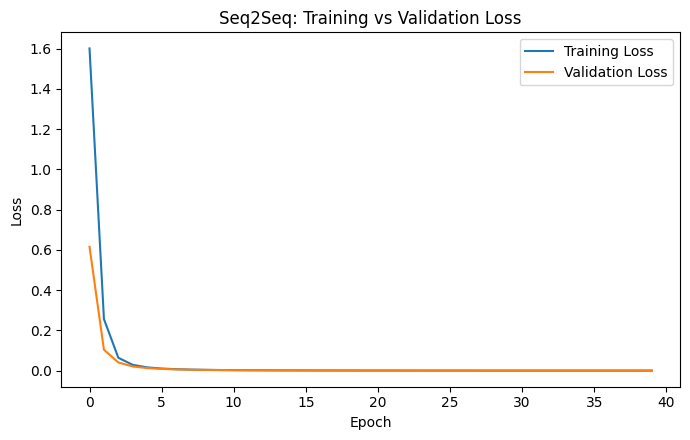

Final training loss: 0.0000  |  Final validation loss: 0.0000


In [69]:
# Plot: training / validation loss for the seq2seq model
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_seq2seq.history["loss"], label="Training Loss")
ax.plot(history_seq2seq.history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Seq2Seq: Training vs Validation Loss")
ax.legend()
plt.tight_layout()
plt.savefig("seq2seq_loss_curve.png", dpi=150)
plt.show()

final_train_loss = history_seq2seq.history["loss"][-1]
final_val_loss = history_seq2seq.history["val_loss"][-1]
print(f"Final training loss: {final_train_loss:.4f}  |  Final validation loss: {final_val_loss:.4f}")


In [70]:
# 5. Build separate inference encoder/decoder models for step-by-step (autoregressive) generation
encoder_model = keras.Model(encoder_inputs, encoder_states, name="Encoder_Inference")

dec_state_h_in = layers.Input(shape=(LATENT_DIM,))
dec_state_c_in = layers.Input(shape=(LATENT_DIM,))
dec_single_input = layers.Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_input)
dec_out, dec_h, dec_c = decoder_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_out = decoder_dense(dec_out)
decoder_model = keras.Model(
    [dec_single_input, dec_state_h_in, dec_state_c_in],
    [dec_out, dec_h, dec_c],
    name="Decoder_Inference"
)

def predict_sequence(input_seq):
    # input_seq: shape (1, SEQ_LEN)
    states = encoder_model.predict(input_seq, verbose=0)
    target_token = np.array([[START_TOKEN]])
    output_tokens = []
    for _ in range(SEQ_LEN):
        probs, h, c = decoder_model.predict([target_token, states[0], states[1]], verbose=0)
        next_token = np.argmax(probs[0, -1, :])
        output_tokens.append(next_token)
        target_token = np.array([[next_token]])
        states = [h, c]
    return np.array(output_tokens)


In [75]:
# Faster batched evaluation - replace the loop-based cell with this
N = len(X_test)

# 1. Encode the entire test set at once
states = encoder_model.predict(X_test, verbose=0)
state_h, state_c = states

# 2. Decode step-by-step, but batched across ALL examples at once
target_tokens = np.full((N, 1), START_TOKEN)
all_preds = np.zeros((N, SEQ_LEN), dtype=int)

for t in range(SEQ_LEN):
    probs, state_h, state_c = decoder_model.predict([target_tokens, state_h, state_c], verbose=0)
    next_tokens = np.argmax(probs[:, -1, :], axis=-1)
    all_preds[:, t] = next_tokens
    target_tokens = next_tokens.reshape(-1, 1)

# 3. Compute metrics
correct_tokens = np.sum(all_preds == Y_test)
total_tokens = N * SEQ_LEN
correct_sequences = np.sum(np.all(all_preds == Y_test, axis=1))
total_sequences = N

token_accuracy = correct_tokens / total_tokens * 100
sequence_accuracy = correct_sequences / total_sequences * 100

print(f"Token Accuracy    : {token_accuracy:.2f}%")
print(f"Sequence Accuracy : {sequence_accuracy:.2f}%")
print(f"Final Training Loss   : {final_train_loss:.4f}")
print(f"Final Validation Loss : {final_val_loss:.4f}")

Token Accuracy    : 100.00%
Sequence Accuracy : 100.00%
Final Training Loss   : 0.0000
Final Validation Loss : 0.0000


In [76]:
# 7. Required: display at least 5 test examples (input -> predicted output)
examples_table = pd.DataFrame({
    "Sample": list(range(1, 6)),
    "Input Sequence": [list(X_test[i]) for i in range(5)],
    "True Output": [list(Y_test[i]) for i in range(5)],
    "Predicted Output": [list(all_preds[i]) for i in range(5)],
})
examples_table


,Sample,Input Sequence,True Output,Predicted Output
0,1,"[1, 0, 8, 9]","[9, 8, 0, 1]","[9, 8, 0, 1]"
1,2,"[6, 3, 4, 0]","[0, 4, 3, 6]","[0, 4, 3, 6]"
2,3,"[2, 8, 0, 7]","[7, 0, 8, 2]","[7, 0, 8, 2]"
3,4,"[1, 5, 6, 4]","[4, 6, 5, 1]","[4, 6, 5, 1]"
4,5,"[8, 5, 9, 5]","[5, 9, 5, 8]","[5, 9, 5, 8]"


In [77]:
# 8. Save results for the consolidated report (Part 8)
results_seq2seq = {
    "token_accuracy": token_accuracy,
    "sequence_accuracy": sequence_accuracy,
    "training_loss": float(final_train_loss),
    "validation_loss": float(final_val_loss),
    "training_time_sec": seq2seq_train_time,
    "parameters": int(seq2seq_model.count_params()),
    "examples": [
        {"input": list(map(int, X_test[i])), "true": list(map(int, Y_test[i])),
         "predicted": list(map(int, all_preds[i]))}
        for i in range(5)
    ]
}
with open("results_seq2seq.json", "w") as f:
    json.dump(results_seq2seq, f, indent=2)
print("Saved results_seq2seq.json")


Saved results_seq2seq.json


In [78]:
# 1. Load every results file
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def safe_load(path):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"WARNING: {path} not found — that section's row(s) will be blank. "
              f"Re-run the corresponding Part and re-download it into this session.")
        return None

results_rnn        = safe_load("results_rnn.json")
results_lstm       = safe_load("results_lstm.json")
results_gru        = safe_load("results_gru.json")
results_seq_length = safe_load("results_seq_length.json")
results_video       = safe_load("results_video.json")
results_seq2seq     = safe_load("results_seq2seq.json")


In [79]:
# 2. Consolidated Results table (Section 25) -- RNN / LSTM / GRU / CNN-LSTM-GRU
def g(d, key, default=None):
    return d.get(key, default) if d is not None else default

# Pick the best-performing video head (as reported in Part 6) for the consolidated row
video_best_name, video_best = None, {}
if results_video is not None:
    video_best_name = results_video.get("best_model_reported")
    video_best = results_video.get("results", {}).get(video_best_name, {})

consolidated = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU", f"CNN-{video_best_name}" if video_best_name else "CNN-LSTM/GRU"],
    "Accuracy (%)": [
        round(g(results_rnn, "accuracy"), 2) if results_rnn else None,
        round(g(results_lstm, "accuracy"), 2) if results_lstm else None,
        round(g(results_gru, "accuracy"), 2) if results_gru else None,
        round(video_best.get("accuracy"), 2) if video_best.get("accuracy") is not None else None,
    ],
    "Precision (%)": [
        round(g(results_rnn, "precision"), 2) if results_rnn else None,
        round(g(results_lstm, "precision"), 2) if results_lstm else None,
        round(g(results_gru, "precision"), 2) if results_gru else None,
        round(video_best.get("precision"), 2) if video_best.get("precision") is not None else None,
    ],
    "Recall (%)": [
        round(g(results_rnn, "recall"), 2) if results_rnn else None,
        round(g(results_lstm, "recall"), 2) if results_lstm else None,
        round(g(results_gru, "recall"), 2) if results_gru else None,
        round(video_best.get("recall"), 2) if video_best.get("recall") is not None else None,
    ],
    "F1 (%)": [
        round(g(results_rnn, "f1"), 2) if results_rnn else None,
        round(g(results_lstm, "f1"), 2) if results_lstm else None,
        round(g(results_gru, "f1"), 2) if results_gru else None,
        round(video_best.get("f1"), 2) if video_best.get("f1") is not None else None,
    ],
    "Parameters": [
        g(results_rnn, "parameters"),
        g(results_lstm, "parameters"),
        g(results_gru, "parameters"),
        video_best.get("parameters"),
    ],
})
consolidated


,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
0,RNN,81.39,81.36,81.39,81.30,1974
1,LSTM,93.89,94.22,93.89,93.82,6006
2,GRU,93.89,94.64,93.89,93.76,4758
3,CNN-GRU,100.00,100.00,100.00,100.00,126309


In [80]:
# 3. Separate table for the sequence-to-sequence task (Section 25)
if results_seq2seq is not None:
    seq2seq_table = pd.DataFrame({
        "Metric": ["Token Accuracy (%)", "Sequence Accuracy (%)", "Training Loss",
                   "Validation Loss", "Parameters", "Training Time (s)"],
        "Value": [
            round(results_seq2seq["token_accuracy"], 2),
            round(results_seq2seq["sequence_accuracy"], 2),
            round(results_seq2seq["training_loss"], 4),
            round(results_seq2seq["validation_loss"], 4),
            results_seq2seq["parameters"],
            round(results_seq2seq["training_time_sec"], 2),
        ]
    })
    display(seq2seq_table)

    examples_df = pd.DataFrame(results_seq2seq["examples"])
    print("\nSample seq2seq predictions:")
    display(examples_df)


,Metric,Value
0,Token Accuracy (%),100.00
1,Sequence Accuracy (%),100.00
2,Training Loss,0.00
3,Validation Loss,0.00
4,Parameters,42539.00
5,Training Time (s),95.47



Sample seq2seq predictions:


,input,true,predicted
0,"[1, 0, 8, 9]","[9, 8, 0, 1]","[9, 8, 0, 1]"
1,"[6, 3, 4, 0]","[0, 4, 3, 6]","[0, 4, 3, 6]"
2,"[2, 8, 0, 7]","[7, 0, 8, 2]","[7, 0, 8, 2]"
3,"[1, 5, 6, 4]","[4, 6, 5, 1]","[4, 6, 5, 1]"
4,"[8, 5, 9, 5]","[5, 9, 5, 8]","[5, 9, 5, 8]"


In [81]:
# 4. Sequence length effect table (Section 17, recap for the report)
if results_seq_length is not None:
    seq_lengths = sorted({int(t) for t in results_seq_length["RNN"].keys()})
    seq_len_df = pd.DataFrame({
        "Sequence Length": seq_lengths,
        "RNN F1":  [round(results_seq_length["RNN"][str(t)], 2) for t in seq_lengths],
        "LSTM F1": [round(results_seq_length["LSTM"][str(t)], 2) for t in seq_lengths],
        "GRU F1":  [round(results_seq_length["GRU"][str(t)], 2) for t in seq_lengths],
    })
    display(seq_len_df)


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,72.01,92.14,92.74
1,64,71.67,92.72,92.08
2,128,75.92,78.24,92.48


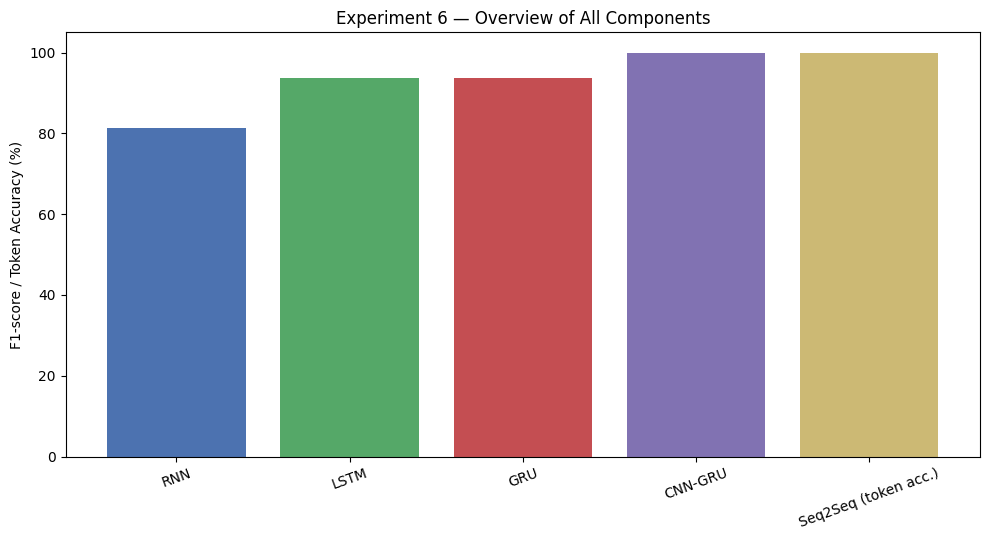

In [82]:
# 5. Master overview bar chart across every component of the experiment
fig, ax = plt.subplots(figsize=(10, 5.5))
names, f1s = [], []
for name, res in [("RNN", results_rnn), ("LSTM", results_lstm), ("GRU", results_gru)]:
    if res is not None:
        names.append(name); f1s.append(res["f1"])
if results_video is not None:
    names.append(f"CNN-{video_best_name}"); f1s.append(video_best.get("f1", 0))
if results_seq2seq is not None:
    names.append("Seq2Seq (token acc.)"); f1s.append(results_seq2seq["token_accuracy"])

ax.bar(names, f1s, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"][:len(names)])
ax.set_ylabel("F1-score / Token Accuracy (%)")
ax.set_title("Experiment 6 — Overview of All Components")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("plot_master_overview.png", dpi=150)
plt.show()


In [84]:
# 6. Save the final consolidated CSVs for inclusion in the Overleaf report
consolidated.to_csv("consolidated_results.csv", index=False)
if results_seq2seq is not None:
    seq2seq_table.to_csv("seq2seq_results.csv", index=False)
if results_seq_length is not None:
    seq_len_df.to_csv("sequence_length_results.csv", index=False)
